In [1]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
import dlib

In [3]:
cat_sticker_path = "/home/jovyan/work/data/cat-whiskers.png"

img_cat_sticker = cv2.imread(cat_sticker_path)

print(img_cat_sticker.shape)

(512, 512, 3)


In [49]:
my_image_path = "/home/jovyan/work/data/image_far.png"

img_bgr = cv2.imread(my_image_path)

print(img_bgr.shape)

(450, 800, 3)


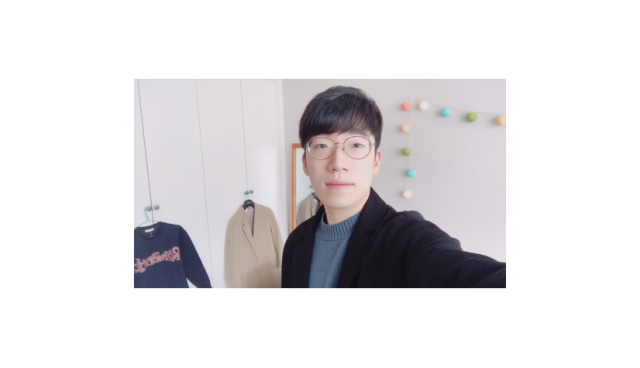

In [50]:
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(8, 8))
plt.imshow(img_rgb)
plt.axis("off")
plt.show()

In [51]:
detector_hog = dlib.get_frontal_face_detector()

dlib_rects = detector_hog(img_rgb, 1)

print(dlib_rects)
print("찾은 얼굴 개수:", len(dlib_rects))

rectangles[[(366, 140) (474, 247)]]
찾은 얼굴 개수: 1


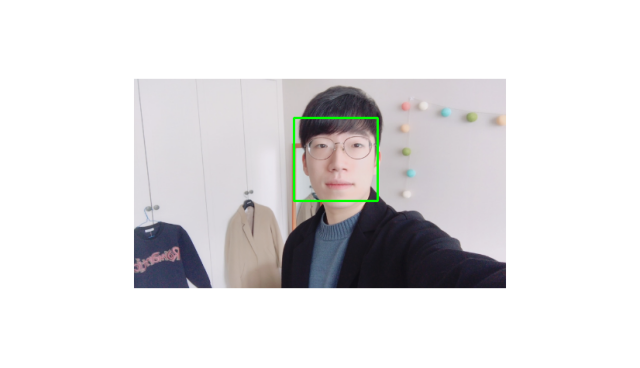

In [52]:
img_show = img_rgb.copy()

for dlib_rect in dlib_rects:
    left = dlib_rect.left()
    top = dlib_rect.top()
    right = dlib_rect.right()
    bottom = dlib_rect.bottom()

    cv2.rectangle(img_show, (left, top), (right, bottom), (0, 255, 0), 2)

plt.figure(figsize=(8, 8))
plt.imshow(img_show)
plt.axis("off")
plt.show()

In [53]:
model_path = "/home/jovyan/work/camera_sticker/models/shape_predictor_68_face_landmarks.dat"

landmark_predictor = dlib.shape_predictor(model_path)

list_landmarks = []

for dlib_rect in dlib_rects:
    points = landmark_predictor(img_rgb, dlib_rect)
    list_points = list(map(lambda p: (p.x, p.y), points.parts()))
    list_landmarks.append(list_points)

print("찾은 얼굴 개수:", len(list_landmarks))
print("랜드마크 개수:", len(list_landmarks[0]))
print("앞 5개 좌표:", list_landmarks[0][:5])

찾은 얼굴 개수: 1
랜드마크 개수: 68
앞 5개 좌표: [(379, 183), (380, 195), (381, 207), (384, 219), (388, 230)]


In [54]:
for dlib_rect, landmark in zip(dlib_rects, list_landmarks):
    # 코 끝 좌표: 33번 landmark
    x_nose = landmark[33][0]
    y_nose = landmark[33][1]

    # 얼굴 박스 크기
    w = dlib_rect.width()
    h = dlib_rect.height()

    # 고양이 수염 스티커 크기
    sticker_width = w
    sticker_height = int(w * 0.5)

    # 고양이 수염 위치 계산
    x = x_nose - sticker_width // 2
    y = y_nose - sticker_height // 2

    print("코 끝 위치:", x_nose, y_nose)
    print("얼굴 박스 크기:", w, h)
    print("스티커 위치:", x, y)
    print("스티커 크기:", sticker_width, sticker_height)

코 끝 위치: 422 210
얼굴 박스 크기: 109 108
스티커 위치: 368 183
스티커 크기: 109 54


In [55]:
# 고양이 수염 이미지 다시 불러오기
cat_sticker_path = "/home/jovyan/work/data/cat-whiskers.png"

img_cat_sticker = cv2.imread(cat_sticker_path)

# 계산한 크기에 맞게 resize
img_cat_sticker = cv2.resize(img_cat_sticker, (sticker_width, sticker_height))

print(img_cat_sticker.shape)

(54, 109, 3)


In [56]:
cat_sticker_path = "/home/jovyan/work/data/cat-whiskers.png"

# 투명배경(alpha 채널)까지 읽기
img_cat_sticker = cv2.imread(cat_sticker_path, cv2.IMREAD_UNCHANGED)

print("원본 수염 스티커 shape:", img_cat_sticker.shape)

# 크기 조절
img_cat_sticker = cv2.resize(img_cat_sticker, (sticker_width, sticker_height))

print("리사이즈 후 shape:", img_cat_sticker.shape)

원본 수염 스티커 shape: (512, 512, 4)
리사이즈 후 shape: (54, 109, 4)


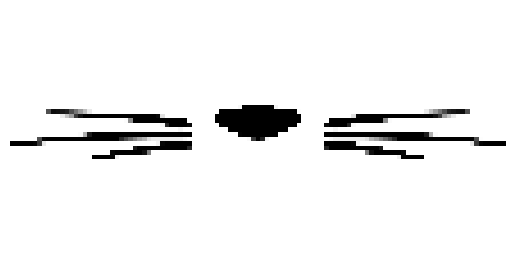

In [57]:
if img_cat_sticker.shape[2] == 4:
    # BGRA -> RGBA
    plt.imshow(cv2.cvtColor(img_cat_sticker, cv2.COLOR_BGRA2RGBA))
else:
    # BGR -> RGB
    plt.imshow(cv2.cvtColor(img_cat_sticker, cv2.COLOR_BGR2RGB))

plt.axis("off")
plt.show()

In [58]:
if img_cat_sticker.shape[2] == 4:
    # RGB 부분과 alpha 부분 분리
    sticker_rgb = img_cat_sticker[:, :, :3]
    sticker_alpha = img_cat_sticker[:, :, 3]
else:
    # 만약 alpha 채널이 없다면, 흰 배경 제거용 마스크 생성
    sticker_rgb = img_cat_sticker
    gray = cv2.cvtColor(img_cat_sticker, cv2.COLOR_BGR2GRAY)
    _, sticker_alpha = cv2.threshold(gray, 250, 255, cv2.THRESH_BINARY_INV)

print("sticker_rgb:", sticker_rgb.shape)
print("sticker_alpha:", sticker_alpha.shape)

sticker_rgb: (54, 109, 3)
sticker_alpha: (54, 109)


In [59]:
img_show = img_bgr.copy()

refined_x = x
refined_y = y

# 왼쪽 바깥으로 나간 경우
if refined_x < 0:
    sticker_rgb = sticker_rgb[:, -refined_x:]
    sticker_alpha = sticker_alpha[:, -refined_x:]
    refined_x = 0

# 위쪽 바깥으로 나간 경우
if refined_y < 0:
    sticker_rgb = sticker_rgb[-refined_y:, :]
    sticker_alpha = sticker_alpha[-refined_y:, :]
    refined_y = 0

# 오른쪽 바깥으로 나간 경우
if refined_x + sticker_rgb.shape[1] > img_show.shape[1]:
    overflow_x = refined_x + sticker_rgb.shape[1] - img_show.shape[1]
    sticker_rgb = sticker_rgb[:, :-overflow_x]
    sticker_alpha = sticker_alpha[:, :-overflow_x]

# 아래쪽 바깥으로 나간 경우
if refined_y + sticker_rgb.shape[0] > img_show.shape[0]:
    overflow_y = refined_y + sticker_rgb.shape[0] - img_show.shape[0]
    sticker_rgb = sticker_rgb[:-overflow_y, :]
    sticker_alpha = sticker_alpha[:-overflow_y, :]

print("보정된 위치:", refined_x, refined_y)
print("보정된 스티커 rgb 크기:", sticker_rgb.shape)
print("보정된 스티커 alpha 크기:", sticker_alpha.shape)

보정된 위치: 368 183
보정된 스티커 rgb 크기: (54, 109, 3)
보정된 스티커 alpha 크기: (54, 109)


In [60]:
sticker_area = img_show[
    refined_y:refined_y + sticker_rgb.shape[0],
    refined_x:refined_x + sticker_rgb.shape[1]
]

# alpha가 0보다 큰 부분만 스티커 사용
mask = sticker_alpha > 0

img_show[
    refined_y:refined_y + sticker_rgb.shape[0],
    refined_x:refined_x + sticker_rgb.shape[1]
] = np.where(mask[:, :, np.newaxis], sticker_rgb, sticker_area)

print("수염 스티커 적용 완료")

수염 스티커 적용 완료


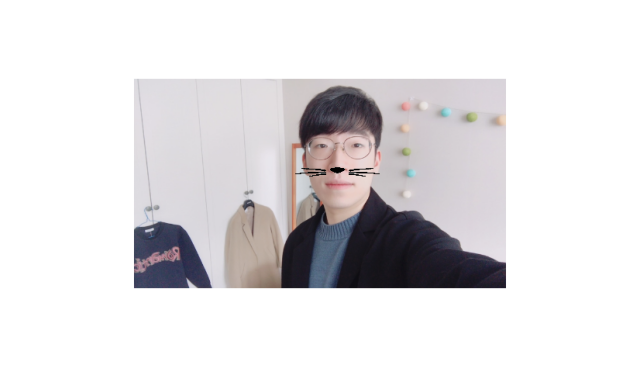

In [61]:
img_show_rgb = cv2.cvtColor(img_show, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(8, 8))
plt.imshow(img_show_rgb)
plt.axis("off")
plt.show()

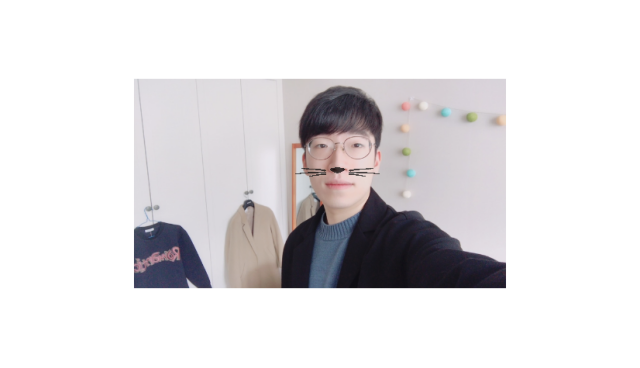

In [62]:
img_show2 = img_bgr.copy()

sticker_area = img_show2[
    refined_y:refined_y + sticker_rgb.shape[0],
    refined_x:refined_x + sticker_rgb.shape[1]
]

# 살짝 섞기
blended = cv2.addWeighted(sticker_area, 0.3, sticker_rgb, 0.7, 0)

mask = sticker_alpha > 0

img_show2[
    refined_y:refined_y + sticker_rgb.shape[0],
    refined_x:refined_x + sticker_rgb.shape[1]
] = np.where(mask[:, :, np.newaxis], blended, sticker_area)

img_show2_rgb = cv2.cvtColor(img_show2, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(8, 8))
plt.imshow(img_show2_rgb)
plt.axis("off")
plt.show()

In [63]:
import cv2
import os
import numpy as np

# 원본 이미지 경로
src_path = "/home/jovyan/work/data/image.png"
save_dir = "/home/jovyan/work/data"

img = cv2.imread(src_path)

# 1. 어두운 이미지
dark = cv2.convertScaleAbs(img, alpha=0.6, beta=0)
cv2.imwrite(os.path.join(save_dir, "image_dark.png"), dark)

# 2. 밝은 이미지
bright = cv2.convertScaleAbs(img, alpha=1.2, beta=30)
cv2.imwrite(os.path.join(save_dir, "image_bright.png"), bright)

# 3. 살짝 회전한 이미지
h, w = img.shape[:2]
center = (w // 2, h // 2)
matrix = cv2.getRotationMatrix2D(center, 15, 1.0)
rotated = cv2.warpAffine(img, matrix, (w, h))
cv2.imwrite(os.path.join(save_dir, "image_rotated.png"), rotated)

# 4. 멀리서 찍은 것처럼 얼굴이 작아진 이미지
small = cv2.resize(img, None, fx=0.6, fy=0.6)
canvas = np.ones_like(img) * 255

sh, sw = small.shape[:2]
start_y = (h - sh) // 2
start_x = (w - sw) // 2

canvas[start_y:start_y+sh, start_x:start_x+sw] = small
cv2.imwrite(os.path.join(save_dir, "image_far.png"), canvas)

print("테스트 이미지 생성 완료")
print(os.listdir(save_dir))

테스트 이미지 생성 완료
['hero.png', 'image_dark.png', 'image_pro.png', 'image_far.png', 'image_rotated.png', 'king.png', 'image_bright.png', 'image.png', 'cat-whiskers.png', 'Untitled1.ipynb', 'Untitled.ipynb', '.ipynb_checkpoints']


# 프로젝트 제출 루브릭 (평가기준체크리스트)

### 얼굴각도, 이미지 밝기, 촬영거리 등 다양한 변수에 따른 영향도를 보고서에 체계적으로 분석하였다.
### 1. 다양한 원본 이미지 적용 결과 및 문제점 분석

카메라 스티커앱을 원본 이미지뿐만 아니라 밝기 변화, 회전 이미지, 얼굴이 작게 보이는 이미지에도 적용해보았다. 정면 원본 이미지에서는 얼굴 영역과 68개 랜드마크가 비교적 정확하게 검출되었고, 고양이 수염 스티커도 코 주변 위치에 자연스럽게 합성되었다.

회전된 이미지에서는 얼굴이 기울어져 있어도 얼굴 검출과 랜드마크 검출은 가능했지만, 스티커는 얼굴 각도에 맞춰 함께 회전하지 않았다. 그 결과 고양이 수염이 얼굴의 기울기와 완전히 맞지 않고, 수평으로 붙어 다소 어색해 보이는 문제가 있었다. 이는 현재 구현 방식이 코 주변 좌표를 기준으로 위치만 계산하고, 얼굴의 회전 각도까지 반영하지 않았기 때문이다.

얼굴이 멀리 있는 것처럼 작게 만든 이미지에서는 스티커가 적용되기는 했지만, 얼굴 크기가 작아지면서 랜드마크 위치가 조금만 어긋나도 스티커 위치가 크게 어색해질 수 있음을 확인했다. 얼굴이 작을수록 detector가 얼굴을 찾기 어려워질 가능성도 있고, landmark 검출 정확도도 낮아질 수 있다.

이미지 밝기가 너무 어두워지거나 밝아지는 경우에는 얼굴의 윤곽, 눈, 코, 입 등의 특징이 흐려질 수 있다. 이 경우 얼굴 검출이나 랜드마크 검출이 불안정해질 수 있으며, 스티커 위치 계산에도 영향을 줄 수 있다.

따라서 다양한 원본 이미지에 적용해본 결과, 얼굴 각도, 이미지 밝기, 촬영 거리와 같은 변수들이 스티커앱의 결과에 영향을 준다는 것을 확인하였다. 현재 구현은 정면 얼굴에서는 잘 동작하지만, 얼굴이 회전하거나 멀리 있는 경우에는 스티커의 위치와 각도를 더 정교하게 보정할 필요가 있다. 개선 방법으로는 눈과 코의 랜드마크 좌표를 이용해 얼굴의 기울기를 계산한 뒤 스티커도 같은 각도로 회전시키는 방법, 작은 얼굴 검출을 위해 이미지 피라미드나 더 강건한 얼굴 검출 모델을 사용하는 방법, 밝기 보정을 적용하는 방법 등을 생각해볼 수 있다.


### 정확한 좌표계산을 통해 고양이 수염의 위치가 원본 얼굴에 잘 어울리게 출력되었다.
dlib을 이용해 얼굴 영역과 68개 랜드마크를 검출한 뒤, 코 주변 landmark 좌표를 기준으로 고양이 수염 스티커의 위치를 계산하였다. 스티커의 가로 크기는 얼굴 bounding box의 너비에 맞추고, 코 좌표를 기준으로 x, y 위치를 조정하여 수염이 얼굴 중앙과 코 주변에 오도록 배치하였다. 그 결과 고양이 수염 스티커가 원본 얼굴에 자연스럽게 합성되었으며, 정확한 좌표 계산을 통해 얼굴 위치에 잘 어울리게 출력되었다.

### 얼굴 영역과 랜드마크를 정확하게 검출하고, 스티커 사진을 합성시키는 데 성공하였다.
얼굴 영역과 랜드마크를 정확하게 찾았고, 이를 이용해 스티커 사진을 얼굴에 잘 합성할 수 있었다.

### 프로젝트 회고록 (고양이 수엽 스티커 앱 만들기)


## 1. 프로젝트 개요

이번 프로젝트에서는 OpenCV와 dlib을 활용하여 얼굴 인식 기반 카메라 스티커 앱을 구현해보았다. 단순히 이미지를 불러와 스티커를 붙이는 것이 아니라, 얼굴 영역을 검출하고 얼굴의 주요 랜드마크를 찾아낸 뒤, 그 좌표를 기준으로 고양이 수염 스티커를 자연스럽게 합성하는 것이 목표였다.

처음에는 카메라 스티커 앱이 단순히 이미지 위에 그림을 얹는 기능이라고 생각했다. 하지만 직접 구현해보니 얼굴의 위치, 코와 입의 위치, 이미지 좌표계, 스티커 크기 조절, 예외 처리 등 여러 요소가 함께 맞아야 자연스러운 결과가 나온다는 것을 알게 되었다.

---

## 2. 진행 과정

먼저 OpenCV를 사용해 원본 이미지를 불러왔다. 이 과정에서 OpenCV는 이미지를 BGR 순서로 읽고, matplotlib은 RGB 순서로 이미지를 보여준다는 차이를 확인했다. 처음 이미지를 출력했을 때 색이 어색하게 보일 수 있는 이유가 바로 이 채널 순서 차이 때문이라는 점을 이해했다.

이후 dlib의 face detector를 사용하여 얼굴 영역을 검출했다. 얼굴 영역은 bounding box 형태로 표시되었고, 초록색 박스를 통해 얼굴이 제대로 검출되었는지 확인할 수 있었다. 그다음 dlib의 68개 face landmark 모델을 사용하여 눈, 코, 입, 턱 주변의 주요 좌표를 찾았다. 얼굴 위에 랜드마크 점을 직접 찍어보면서 모델이 얼굴의 각 부분을 좌표로 인식한다는 것을 시각적으로 확인할 수 있었다.

고양이 수염 스티커를 적용할 때는 코 주변 좌표를 기준으로 위치를 계산했다. 스티커의 가로 크기는 얼굴 bounding box의 너비에 맞추고, 코 좌표를 중심으로 x, y 위치를 조정하였다. 단순히 고정된 위치에 붙이는 것이 아니라 얼굴 크기와 위치에 따라 스티커 크기와 위치가 달라지도록 계산했다는 점이 중요했다.

마지막으로 `np.where()`를 사용하여 스티커의 실제 색이 있는 부분만 원본 이미지 위에 적용하였다. 추가로 `cv2.addWeighted()`를 활용해 원본 이미지와 스티커 이미지를 섞어주면서, 스티커가 너무 딱딱하게 붙은 느낌보다 조금 더 자연스럽게 보이도록 조정했다.

---

## 3. 구현 결과

최종적으로 얼굴 영역과 랜드마크를 정상적으로 검출하였고, 이를 바탕으로 고양이 수염 스티커를 원본 얼굴에 합성하는 데 성공했다. 수염은 코 주변에 위치하도록 계산되었고, 얼굴 크기에 맞게 스티커 크기도 조정되었다.

처음에는 왕관 스티커를 머리 위에 붙이며 좌표 계산과 예외 처리를 연습했다. 이 과정에서 y좌표가 음수가 되면 이미지 범위를 벗어난다는 점을 직접 경험했고, 스티커가 이미지 밖으로 나갈 때 crop과 좌표 보정이 필요하다는 것을 알게 되었다. 이후 고양이 수염 스티커를 적용할 때는 이 경험이 도움이 되었다.

고양이 수염 스티커는 얼굴의 코 주변에 비교적 자연스럽게 적용되었고, `cv2.addWeighted()`를 사용한 결과 원본 이미지와 스티커가 조금 더 부드럽게 섞여 보였다.

---

## 4. 문제점 분석

다양한 원본 이미지에 적용해보면서 몇 가지 문제점도 확인할 수 있었다.

먼저, 정면 얼굴에서는 얼굴 검출과 랜드마크 검출이 비교적 안정적으로 이루어졌다. 하지만 이미지를 회전시킨 경우에는 얼굴 검출과 랜드마크 검출은 가능하더라도, 스티커가 얼굴 각도에 맞춰 함께 회전하지 않아 어색해 보이는 문제가 있었다. 현재 구현은 코 주변 좌표를 기준으로 위치만 계산하기 때문에 얼굴의 기울기까지 반영하지 못한다.

또한 얼굴이 작게 보이는 이미지에서는 랜드마크가 조금만 어긋나도 스티커 위치가 크게 어색해질 수 있었다. 촬영 거리가 멀어져 얼굴 크기가 작아지면 detector가 얼굴을 찾기 어려워질 가능성도 있다.

이미지 밝기도 중요한 요소라고 느꼈다. 너무 어둡거나 밝은 이미지에서는 얼굴의 윤곽이나 코, 입 주변의 특징이 흐려질 수 있고, 그 결과 landmark 검출 정확도가 떨어질 수 있다. 즉, 스티커 앱은 단순히 좌표 계산만 잘한다고 완성되는 것이 아니라, 입력 이미지의 조건에도 영향을 많이 받는다는 것을 알게 되었다.

---

## 5. 배운 점

이번 프로젝트를 통해 컴퓨터 비전에서 좌표 계산이 얼마나 중요한지 알게 되었다. 이미지에서 x좌표는 오른쪽으로 갈수록 커지고, y좌표는 아래로 갈수록 커진다는 기본 좌표계를 이해해야 스티커 위치를 제대로 조정할 수 있었다.

또한 face detection과 face landmark의 차이도 분명하게 이해할 수 있었다. face detection은 얼굴이 있는 큰 영역을 찾는 것이고, face landmark는 그 안에서 눈, 코, 입 같은 세부 위치를 찾는 과정이다. 스티커를 자연스럽게 붙이기 위해서는 단순한 얼굴 검출만으로는 부족하고, landmark 좌표가 필요하다는 점을 직접 확인했다.

그리고 이미지 합성 과정에서 `np.where()`와 `cv2.addWeighted()`의 역할도 배웠다. `np.where()`는 특정 조건에 따라 원본 이미지와 스티커 이미지를 선택적으로 합성하는 데 사용되었고, `cv2.addWeighted()`는 두 이미지를 일정 비율로 섞어 자연스러운 효과를 만드는 데 활용되었다.

---

## 6. 아쉬웠던 점과 개선 방향

이번 프로젝트에서는 정면 얼굴을 기준으로 스티커를 적용하는 데는 성공했지만, 얼굴이 기울어진 경우 스티커도 함께 회전하도록 구현하지는 못했다. 앞으로는 양쪽 눈이나 코의 landmark 좌표를 이용해 얼굴의 회전 각도를 계산하고, 스티커 이미지도 같은 각도로 회전시키는 방법을 적용해보고 싶다.

또한 여러 얼굴이 있는 이미지에서는 각 얼굴마다 스티커를 따로 적용하는 방식도 개선해볼 수 있을 것 같다. 얼굴마다 bounding box와 landmark를 반복적으로 계산하면 여러 사람에게 동시에 스티커를 붙이는 기능도 만들 수 있을 것이다.

실제 카메라 앱처럼 동영상이나 실시간 웹캠에 적용하려면 실행 속도도 중요할 것 같다. 지금은 한 장의 이미지에 대해 처리했지만, 실시간으로 동작하려면 얼굴 검출 속도와 스티커 합성 속도를 더 효율적으로 만드는 과정이 필요하다고 느꼈다.

---

## 7. 최종 회고

이번 프로젝트는 단순한 스티커 앱처럼 보였지만, 실제로는 컴퓨터 비전의 여러 핵심 개념을 경험할 수 있는 실습이었다. 이미지 읽기, 색상 채널 변환, 얼굴 검출, 랜드마크 검출, 좌표 계산, 이미지 합성, 예외 처리까지 하나의 흐름으로 연결되었다.

특히 직접 오류를 만나고 수정하면서 더 많이 배울 수 있었다. 파일 경로를 잘못 입력하거나, `cv2`, `np`를 import하지 않아 오류가 나기도 했고, 스티커 좌표가 이미지 밖으로 벗어나면서 잘리는 문제도 겪었다. 하지만 이런 문제를 하나씩 해결하면서 코드가 어떤 순서로 실행되어야 하는지, 각 변수들이 어떤 역할을 하는지 더 잘 이해하게 되었다.

이번 실습을 통해 얼굴 인식 카메라 앱이 어떻게 동작하는지 기본 원리를 이해할 수 있었다. 앞으로는 얼굴 각도 변화, 다양한 밝기 조건, 여러 사람 얼굴, 실시간 카메라 입력까지 확장해보며 더 완성도 높은 스티커 앱을 만들어보고 싶다.
